# A/B testing en un marketplace — ¿un rediseño de la ficha de producto aumenta el AOV?

**Proyecto de portfolio · metodología CRISP-DM · dataset Brazilian E-Commerce by Olist**

Este notebook es la **capa de presentación**: lee los resultados que genera el pipeline y cuenta
la historia. **No calcula nada.** Todo el cálculo vive en `src/` y se ejecuta con un único
comando:

```bash
python run_all.py      # ~5 min, semillas fijas -> resultado determinista
```

`run_all.py` corre las 6 fases de CRISP-DM en orden, verifica cada salida y termina con un
informe de reproducibilidad. Este notebook asume que ya se ha ejecutado.

> **Nota de honestidad metodológica.** El dataset de Olist no trae grupos control/tratamiento.
> La asignación se **simula** y el efecto del tratamiento se **inyecta de forma declarada**
> (modelo diluido: 20 % de los tratados responde con +25 %, efecto medio +5 %). El objetivo **no**
> es descubrir si el rediseño funciona —lo sabemos, porque el efecto lo ponemos nosotros—, sino
> **demostrar que el diseño y el análisis controlan los falsos positivos y recuperan sin sesgo un
> efecto de tamaño conocido**. Es la competencia que se evalúa en un rol de experimentación.

In [1]:
import json
import os
import sys
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir("..")
sys.path.insert(0, "src")

import pandas as pd
from IPython.display import Image, display

import config

TABLES = config.OUT_TABLES
FIGURES = config.OUT_FIGURES


def rj(name):
    return json.loads((TABLES / name).read_text(encoding="utf-8"))


def L(x):
    return [round(float(v), 3) for v in x]


_needed = ["fase2_resumen.json", "fase3_balance.csv", "fase3_srm.csv",
           "fase4_resumen.json", "fase5_resumen.json"]
_missing = [f for f in _needed if not (TABLES / f).exists()]
if _missing:
    raise SystemExit(f"Faltan resultados {_missing}. Ejecuta primero:  python run_all.py")
print("Resultados encontrados. Parámetros del proyecto:")
print(" ", config.summary())

Resultados encontrados. Parámetros del proyecto:
  SEED=42 ALPHA=0.05 | efecto diluido p_resp=0.2 delta_resp=0.25 -> ATE=5.00% | MDE=3.0% | ventana 2017-01-01..2018-09-01 | winsor q=0.995 | n_sim_aa=2000


---
## Fase 1 — Comprensión del negocio (Business Understanding)

**Contexto.** Olist es un marketplace que conecta a pequeños vendedores brasileños con los grandes
canales de venta online. El equipo de Producto propone un **rediseño de la ficha de producto**
(recomendaciones de *cross-sell* + barra de progreso hacia envío gratuito) con la hipótesis de que
**aumenta el valor medio del pedido (AOV)** sin dañar la satisfacción ni las cancelaciones.

**Limitación estructural (decisión de alcance).** El dataset arranca en el pedido: no hay sesiones
ni carritos → **no se puede medir conversión**. La métrica primaria es el **AOV**.

| Elemento | Definición |
|---|---|
| **H0** | μ_treatment − μ_control = 0 |
| **H1** | μ_treatment − μ_control ≠ 0 (bilateral, α = 0,05) |
| **Métrica primaria** | AOV = Σ `order_items.price` por pedido (valor de mercancía) |
| **Guardrails** | G1 review_score · G2 cancelación · G3 flete · G4 nº de ítems — regla de **dos puertas** (significativo **Y** magnitud) + corrección Benjamini-Hochberg |
| **MDE de relevancia** | **+3 %** — *derivado* de un modelo de break-even (`src/mde_cost_model.py`) |
| **Regla de decisión** | LANZAR si p < 0,05 **y** IC 95 % del lift enteramente por encima de +3 % **y** ningún guardrail degradado; ITERAR si significativo pero el IC toca el MDE; NO LANZAR en otro caso |

Detalle: `docs/01_business_understanding.md`.

In [2]:
print("Parámetros declarados (params.yaml -> src/config.py):")
print(f"  semilla            : {config.SEED}")
print(f"  alpha (bilateral)  : {config.ALPHA}")
print(f"  efecto diluido     : {config.P_RESP:.0%} responde con +{config.DELTA_RESP:.0%}"
      f"  ->  ATE = +{config.ATE:.0%}")
print(f"  MDE de relevancia  : +{config.MDE_RELEVANCIA:.0f}%")
print(f"  ventana temporal   : {config.WINDOW_START} .. {config.WINDOW_END}")

Parámetros declarados (params.yaml -> src/config.py):
  semilla            : 42
  alpha (bilateral)  : 0.05
  efecto diluido     : 20% responde con +25%  ->  ATE = +5%
  MDE de relevancia  : +3%
  ventana temporal   : 2017-01-01 .. 2018-09-01


---
## Fase 2 — Comprensión de los datos (Data Understanding)

Dataset: [Brazilian E-Commerce by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)
· licencia **CC BY-NC-SA 4.0** (verificada en la descarga) · ~100 k pedidos · 9 tablas relacionales.

MÉTRICA PRIMARIA — AOV (valor de mercancía por pedido)
  n = 98,199   media = R$ 137.42   mediana = R$ 86.90
  CV = 1.523   skew = 9.8   curtosis(exceso) = 271
  log(AOV): skew = 0.24   curtosis = 0.33  (rango robusto)

  97.0% de clientes con 1 solo pedido -> unidad de aleatorización ≈ unidad de análisis
  Lectura: AOV muy asimétrico; a n grande la media es normal por el TCL -> Welch-t primario.


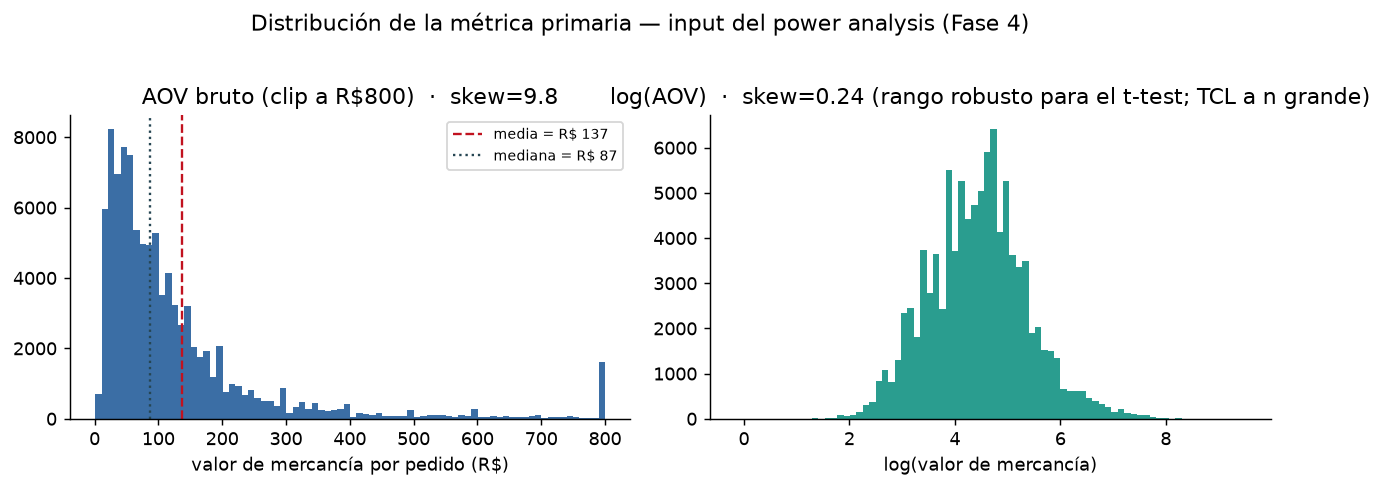

In [3]:
f2 = rj("fase2_resumen.json")
aov = f2["AOV_merch_value"]
logaov = f2["AOV_log_merch"]
print("MÉTRICA PRIMARIA — AOV (valor de mercancía por pedido)")
print(f"  n = {aov['n']:,}   media = R$ {aov['mean']:.2f}   mediana = R$ {aov['median']:.2f}")
print(f"  CV = {aov['cv']:.3f}   skew = {aov['skew']:.1f}   curtosis(exceso) = {aov['kurtosis_excess']:.0f}")
print(f"  log(AOV): skew = {logaov['skew']:.2f}   curtosis = {logaov['kurtosis_excess']:.2f}  (rango robusto)")
print(f"\n  {f2['pedidos_por_cliente']['pct_clientes_1_pedido']:.1f}% de clientes con 1 solo pedido "
      f"-> unidad de aleatorización ≈ unidad de análisis")
print("  Lectura: AOV muy asimétrico; a n grande la media es normal por el TCL -> Welch-t primario.")
display(Image(str(FIGURES / "f2_02_distribucion_aov.png")))

**Limitaciones de validez** (`docs/02_data_understanding.md` §2.7): sin aleatorización real ni capa
de tráfico; efecto inyectado de forma declarada; ventana histórica de 2 años (no un experimento de
2–4 semanas); recompra ~3 % → sin métrica de retención; mercado único.

---
## Fase 3 — Preparación de los datos (Data Preparation)

Limpieza dirigida a la pregunta experimental. Cada paso queda trazado.
Decisiones: ventana 2017-01/2018-08 · dedup de reseñas por timestamp · **dedup a 1 pedido/cliente**
(mueve el AOV solo −0,35 %) · **winsorización p99,5 solo para el contraste**.

In [4]:
display(pd.read_csv(TABLES / "fase3_transformaciones.csv"))

,paso,n_antes,n_despues,delta,justificacion
0,ventana_temporal,99441,99092,-349,"restringir a [2017-01-01, 2018-09-01) por real..."
1,estados_validos,99092,97905,-1187,"conservar ['approved', 'delivered', 'invoiced'..."
2,pedidos_con_items,97905,97905,0,excluir pedidos sin líneas en order_items (no ...
3,dedup_1_pedido_cliente,97905,94703,-3202,quedarse con el primer pedido de cada cliente ...


,covariable,tipo,SMD,p_value,balanceada
0,n_items,continua,-0.0036,0.5790,True
1,freight_value,continua,0.0067,0.3046,True
2,customer_state,categórica (27 niveles),0.0127,0.9185,True
3,cat_dominante,categórica (72 niveles),0.0200,0.3203,True
4,payment_type,categórica (4 niveles),0.0085,0.6227,True
5,mes_compra,categórica (20 niveles),0.0153,0.6930,True


Todas |SMD| < 0,10: True   ·   ningún ómnibus significativo: True
SRM check: control=47280 treatment=47423  chi2=0.216 p=0.642  ->  sin SRM


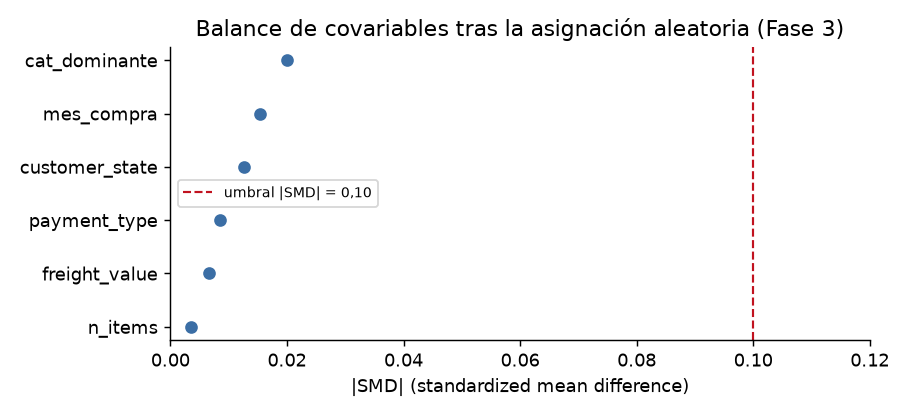

In [5]:
bal = pd.read_csv(TABLES / "fase3_balance.csv")
srm = pd.read_csv(TABLES / "fase3_srm.csv").iloc[0]
display(bal[["covariable", "tipo", "SMD", "p_value", "balanceada"]])
print(f"Todas |SMD| < 0,10: {bal['balanceada'].all()}   ·   ningún ómnibus significativo: "
      f"{(bal['p_value'] >= 0.05).all()}")
print(f"SRM check: control={srm['n_control']} treatment={srm['n_treatment']}  "
      f"chi2={srm['chi2']:.3f} p={srm['p_value']:.3f}  ->  {srm['veredicto']}")
display(Image(str(FIGURES / "f3_01_balance.png")))

---
## Fase 4 — Modeling (diseño estadístico del experimento)

POWER ANALYSIS
  [crudo       ] MDE detectable 80% = +2.789%   potencia(ATE=+5%) = 1.0   lift medio (1000 sims) = 4.999%  (sesgo -0.001 pp)
  [winsor_p99.5] MDE detectable 80% = +2.336%   potencia(ATE=+5%) = 1.0   lift medio (1000 sims) = 5.006%  (sesgo 0.006 pp)

  Penalización de potencia por efecto diluido: -0.11 pp -> despreciable (la varianza natural del AOV, CV≈1,5, domina).


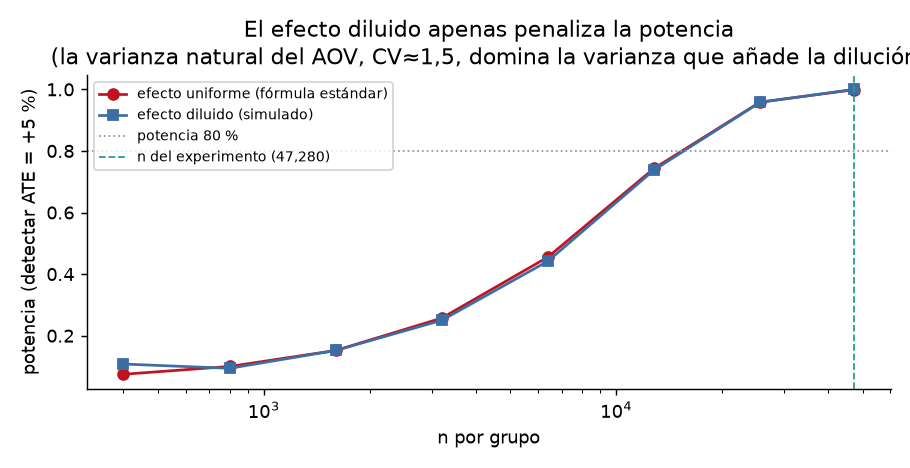

In [6]:
f4 = rj("fase4_resumen.json")
pw = f4["1_power_analysis"]
print("POWER ANALYSIS")
for k in ("crudo", "winsor_p99.5"):
    r = pw[k]
    print(f"  [{k:12}] MDE detectable 80% = +{r['mde_rel_detectable_80pct_pct']}%   "
          f"potencia(ATE=+5%) = {r['power_efecto_diluido_+5pct_ATE']}   "
          f"lift medio (1000 sims) = {r['lift_medio_estimado_sim_pct']}%  (sesgo {r['sesgo_estimador_pp']} pp)")
print(f"\n  Penalización de potencia por efecto diluido: "
      f"{pw['crudo']['penalizacion_potencia_por_dilucion_pp']} pp -> despreciable "
      f"(la varianza natural del AOV, CV≈1,5, domina).")
display(Image(str(FIGURES / "f4_04_power_vs_n.png")))

VERIFICACIÓN DE SUPUESTOS
  Normalidad de los datos brutos : p = 0.0  (no normal, esperado)
  Normalidad de la media (TCL)   : p = 0.8259  -> Welch-t válido
  Homocedasticidad SIN efecto    : Levene p = 0.2048
  Homocedasticidad CON efecto    : Levene p = 1.64e-06  -> varianzas desiguales bajo H1 -> usar Welch, NO Student


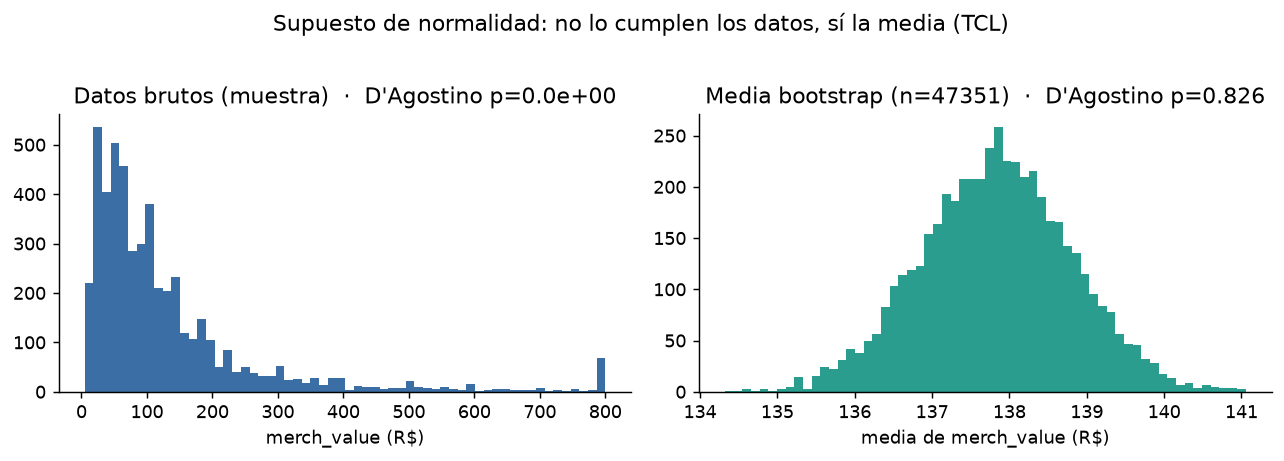

In [7]:
asm = f4["2_supuestos"]
print("VERIFICACIÓN DE SUPUESTOS")
print(f"  Normalidad de los datos brutos : p = {asm['normalidad_datos_brutos']['p']}  (no normal, esperado)")
print(f"  Normalidad de la media (TCL)   : p = {asm['normalidad_de_la_media_bootstrap']['p']}  -> Welch-t válido")
print(f"  Homocedasticidad SIN efecto    : Levene p = {asm['homocedasticidad_sin_efecto']['p']}")
print(f"  Homocedasticidad CON efecto    : Levene p = {asm['homocedasticidad_con_efecto_diluido']['p']}"
      f"  -> varianzas desiguales bajo H1 -> usar Welch, NO Student")
display(Image(str(FIGURES / "f4_01_tcl_normalidad.png")))

CALIBRACIÓN A/A  (2.000 particiones aleatorias, sin efecto)
  [merch_value   ] falsos positivos = 0.050  (IC95 [0.04, 0.059])  ·  KS p-valores = 0.527  ->  calibrado
  [merch_value_w ] falsos positivos = 0.050  (IC95 [0.04, 0.06])  ·  KS p-valores = 0.933  ->  calibrado
  [log_merch     ] falsos positivos = 0.050  (IC95 [0.04, 0.06])  ·  KS p-valores = 0.725  ->  calibrado


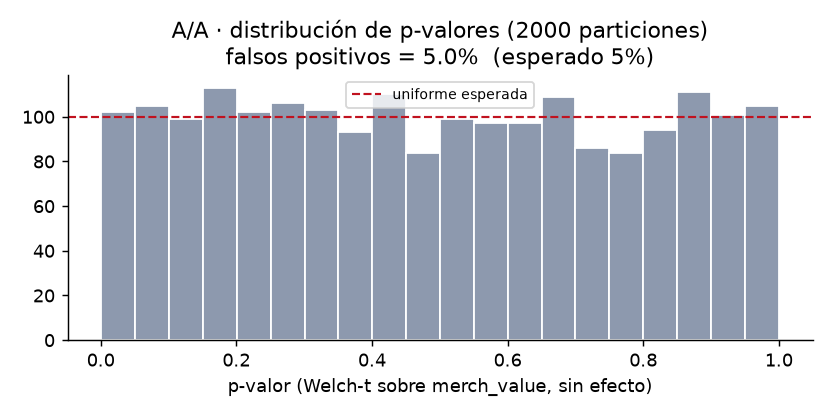

In [8]:
print("CALIBRACIÓN A/A  (2.000 particiones aleatorias, sin efecto)")
for k, v in f4["3_aa_calibracion"].items():
    print(f"  [{k:14}] falsos positivos = {v['tasa_falsos_positivos_alpha_0.05']:.3f}  "
          f"(IC95 {L(v['IC95_tasa'])})  ·  KS p-valores = {v['KS_vs_uniforme_p']:.3f}  ->  {v['veredicto']}")
display(Image(str(FIGURES / "f4_02_aa_pvalores.png")))

TEST A/B  —  efecto diluido inyectado (SEED=42)
  Welch · AOV winsor : +5.666%  IC95 [3.994, 7.337]%  ·  p = 3.095e-11
  Welch · AOV crudo  : +6.111%  [4.091, 8.131]%
  bootstrap (10k)    : [4.048, 8.187]%
  el efecto verdadero (+5 %) está dentro del IC: True

  GUARDRAILS (Benjamini-Hochberg):
    G1_review_score       p ajustado BH = 0.804  ->  degradado: False
    G2_cancelacion        p ajustado BH = 0.609  ->  degradado: False
    G3_freight_value      p ajustado BH = 0.609  ->  degradado: False
    G4_n_items            p ajustado BH = 0.772  ->  degradado: False


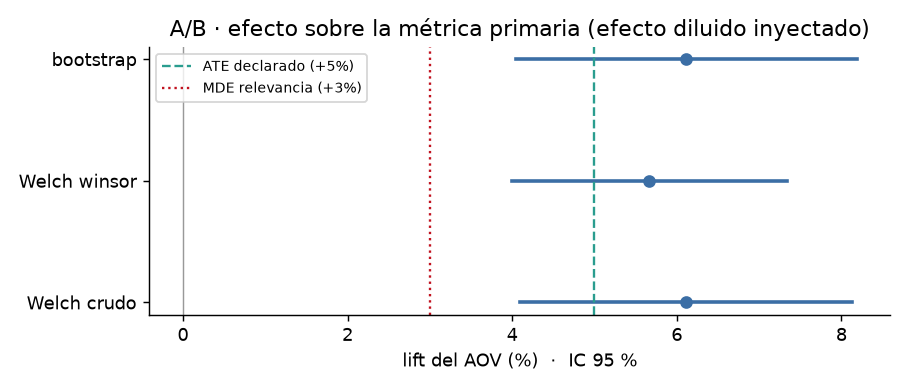

In [9]:
p = f4["4_ab_test"]["primario"]
print("TEST A/B  —  efecto diluido inyectado (SEED=42)")
print(f"  Welch · AOV winsor : +{p['Welch_winsor_p99.5']['lift_rel_pct']}%  "
      f"IC95 {L(p['Welch_winsor_p99.5']['IC95_lift_pct'])}%  ·  p = {p['Welch_winsor_p99.5']['p_value']}")
print(f"  Welch · AOV crudo  : +{p['Welch_crudo']['lift_rel_pct']}%  {L(p['Welch_crudo']['IC95_lift_pct'])}%")
print(f"  bootstrap (10k)    : {L(p['bootstrap_ratio']['IC95_lift_pct'])}%")
print(f"  el efecto verdadero (+5 %) está dentro del IC: {p['Welch_winsor_p99.5']['ATE_5pct_en_IC']}")
print("\n  GUARDRAILS (Benjamini-Hochberg):")
for g, v in f4["4_ab_test"]["guardrails"].items():
    print(f"    {g:20}  p ajustado BH = {v['p_ajustado_BH']:.3f}  ->  degradado: {v['significativo_tras_BH']}")
display(Image(str(FIGURES / "f4_03_ab_efecto.png")))

### Fase 4 · robustez adicional (mejoras de la auditoría global)

In [10]:
ms = f4["8_ab_multiseed"]
print("A/B MULTI-SEMILLA (500 réplicas: re-split + re-inyección)")
for k in ("crudo", "winsor_p99.5"):
    m = ms[k]
    print(f"  [{k:12}] lift medio = {m['lift_medio_pct']}%   sesgo = {m['sesgo_pp']} pp   "
          f"cobertura IC95 del +5% = {m['cobertura_IC95_del_+5pct']}")
print("  -> crudo INSESGADO y con cobertura nominal; la winsorización mete −0,36 pp de sesgo.")

gr = f4["6_guardrail_regression"]
print("\nREGRESIÓN INYECTADA EN G1 (regla de dos puertas: significativo Y magnitud >= 0,05)")
for s in gr["escenarios"]:
    print(f"  inyectado {s['regresion_inyectada_pts']:+.2f} pts -> p={s['p_value']:.1e}   "
          f"bloquea (regla Y): {s['regla_AND_(significativo Y magnitud)']}")
print("  -> a n grande TODO es significativo; la regla necesita la puerta de magnitud.")

het = f4["7_efecto_heterogeneo"]
print(f"\nVARIANTE CON EFECTO HETEROGÉNEO REAL (concentrado bajo R$ {het['umbral_envio_gratis_R$']:.0f})")
print(f"  lift en banda = {het['lift_en_banda_pct']}%   fuera = {het['lift_fuera_de_banda_pct']}%   "
      f"interacción p = {het['p_interaccion_cerca_del_umbral_HC3']}")
print("  -> el análisis de segmentos SÍ detecta heterogeneidad cuando existe.")

cl = f4["9_clustered_se"]
print("\nTODOS LOS PEDIDOS + SE POR CLÚSTER DE CLIENTE")
print(f"  lift = {cl['lift_pct_todos_los_pedidos']}%  (dedup: {cl['lift_pct_dedup_1_pedido_cliente_ref']}%)   "
      f"·  el clustering infla el SE solo {cl['inflacion_SE_por_clustering_pct']}%")

A/B MULTI-SEMILLA (500 réplicas: re-split + re-inyección)
  [crudo       ] lift medio = 4.969%   sesgo = -0.031 pp   cobertura IC95 del +5% = 0.942
  [winsor_p99.5] lift medio = 4.64%   sesgo = -0.36 pp   cobertura IC95 del +5% = 0.92
  -> crudo INSESGADO y con cobertura nominal; la winsorización mete −0,36 pp de sesgo.

REGRESIÓN INYECTADA EN G1 (regla de dos puertas: significativo Y magnitud >= 0,05)
  inyectado +0.00 pts -> p=8.0e-01   bloquea (regla Y): False
  inyectado -0.03 pts -> p=1.2e-03   bloquea (regla Y): False
  inyectado -0.05 pts -> p=2.8e-08   bloquea (regla Y): False
  inyectado -0.08 pts -> p=1.6e-19   bloquea (regla Y): True
  -> a n grande TODO es significativo; la regla necesita la puerta de magnitud.

VARIANTE CON EFECTO HETEROGÉNEO REAL (concentrado bajo R$ 150)
  lift en banda = 7.05%   fuera = 1.52%   interacción p = 2.14e-15
  -> el análisis de segmentos SÍ detecta heterogeneidad cuando existe.

TODOS LOS PEDIDOS + SE POR CLÚSTER DE CLIENTE
  lift = 5.713%  (

### Fase 4 · MDE de relevancia derivado de un modelo de costes

El +3 % no se aserta: es el *break-even* del rediseño (margen incremental = coste de propiedad).

horizonte_payback_anios,1,2,3
pedidos_anio,,,
58700,34.196,21.243,16.925
250000,8.029,4.988,3.974
1000000,2.007,1.247,0.994
5000000,0.401,0.249,0.199
20000000,0.100,0.062,0.050


El +3% es válido para un marketplace con >= ~415.000 pedidos/año (payback 2 años).


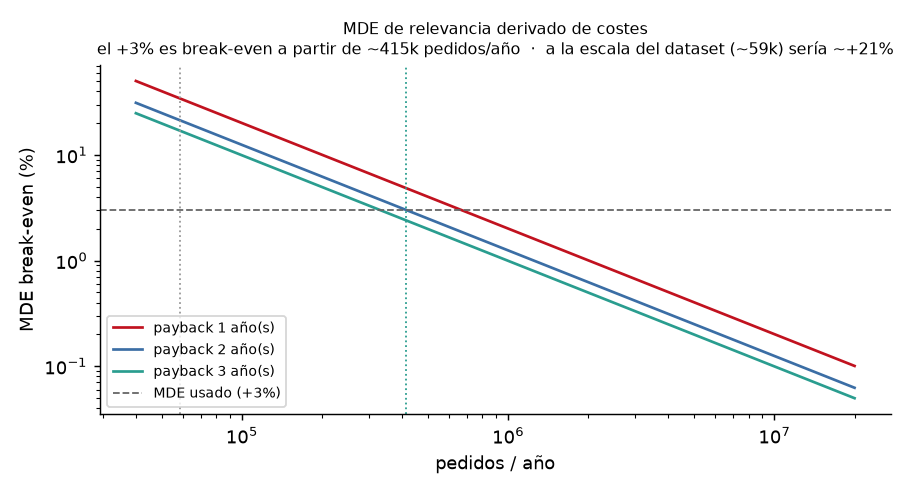

In [11]:
_mde = pd.read_csv(TABLES / "mde_cost_model.csv")
display(_mde.pivot(index="pedidos_anio", columns="horizonte_payback_anios", values="MDE_breakeven_pct"))
print("El +3% es válido para un marketplace con >= ~415.000 pedidos/año (payback 2 años).")
display(Image(str(FIGURES / "f_mde_breakeven.png")))

---
## Fase 5 — Evaluación (Evaluation)

In [12]:
f5 = rj("fase5_resumen.json")
prim, imp, anc = f5["1_resultado_primario"], f5["2_impacto_negocio"], f5["3_ancova"]
print("SIGNIFICANCIA vs RELEVANCIA")
print(f"  Efecto primario : +{prim['lift_pct']}%   IC95 {L(prim['IC95_lift_pct'])}%   log10(p) = {prim['log10_p']}")
print(f"  ¿significativo?  : {prim['significativo']}")
print(f"  ¿IC entero sobre el MDE +3 %?  : {prim['ci_entero_sobre_MDE']}   ->  RELEVANTE: {prim['relevante']}")
print(f"\n  ANCOVA (ajuste por covariables): +{anc['con_ajuste']['lift_pct']}%  "
      f"IC95 {L(anc['con_ajuste']['ci95_pct'])}%  ·  SE −{anc['reduccion_SE_pct']}%")
print("\nIMPACTO ECONÓMICO ESTIMADO")
print(f"  Uplift de GMV de mercancía : +R$ {imp['uplift_GMV_anual_R$']:,}/año  "
      f"(IC [{imp['uplift_GMV_anual_IC95_R$'][0]:,}, {imp['uplift_GMV_anual_IC95_R$'][1]:,}])")
print(f"  ≈ +R$ {imp['uplift_ingreso_marketplace_anual_R$_asumiendo_comision_15pct']:,}/año de comisión (15 %)")

SIGNIFICANCIA vs RELEVANCIA
  Efecto primario : +5.666%   IC95 [3.994, 7.337]%   log10(p) = -10.51
  ¿significativo?  : True
  ¿IC entero sobre el MDE +3 %?  : True   ->  RELEVANTE: True

  ANCOVA (ajuste por covariables): +5.193%  IC95 [3.709, 6.677]%  ·  SE −11.23%

IMPACTO ECONÓMICO ESTIMADO
  Uplift de GMV de mercancía : +R$ 456,084/año  (IC [321,514, 590,655])
  ≈ +R$ 68,413/año de comisión (15 %)


SEGMENTOS PRE-ESPECIFICADOS — interacción log(AOV), Wald HC3, + Benjamini-Hochberg
  cesta           p bruto = 0.924   p BH = 0.924   heterogéneo: False
  payment_type    p bruto = 0.377   p BH = 0.924   heterogéneo: False
  macro_region    p bruto = 0.680   p BH = 0.924   heterogéneo: False
  trimestre       p bruto = 0.794   p BH = 0.924   heterogéneo: False
  cat_grupo       p bruto = 0.135   p BH = 0.676   heterogéneo: False

P-HACKING — 38 cortes exploratorios (esperados por azar ≈ 1,9)
  test_en_NIVEL_(mv_w)              nominales = 5   tras BH = 3   tras Bonferroni = 2
  test_en_LOG_(efecto_relativo)     nominales = 2   tras BH = 0   tras Bonferroni = 0
  -> en la escala equivocada (nivel) los artefactos del efecto multiplicativo sobreviven a
     Bonferroni; en la escala correcta (log) no queda nada. Corregir no salva un estimando malo.


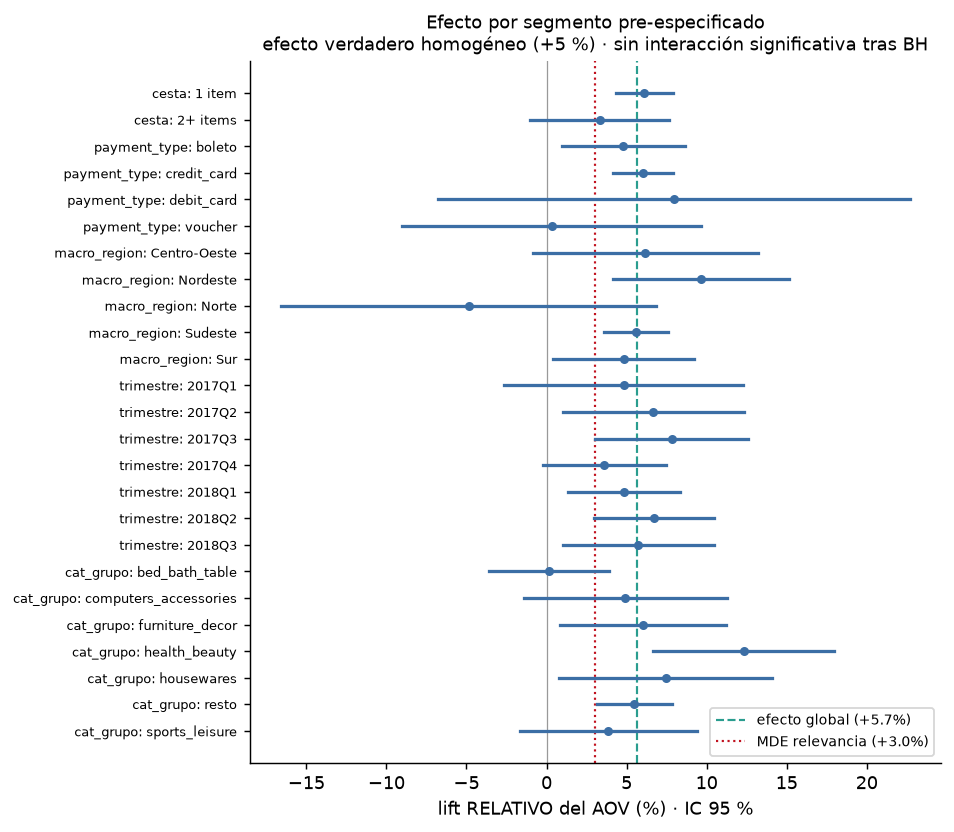

In [13]:
print("SEGMENTOS PRE-ESPECIFICADOS — interacción log(AOV), Wald HC3, + Benjamini-Hochberg")
for k, v in f5["4_segmentos"]["test_interaccion"].items():
    print(f"  {k:14}  p bruto = {v['p_bruto']:.3f}   p BH = {v['p_BH']:.3f}   "
          f"heterogéneo: {v['heterogeneidad_significativa_tras_BH']}")
print("\nP-HACKING — 38 cortes exploratorios (esperados por azar ≈ 1,9)")
ph = f5["5_p_hacking"]
for esc in ("test_en_NIVEL_(mv_w)", "test_en_LOG_(efecto_relativo)"):
    s = ph[esc]
    print(f"  {esc:32}  nominales = {s['nominales_p<0.05']['n']}   tras BH = {s['tras_BH']['n']}   "
          f"tras Bonferroni = {s['tras_Bonferroni']}")
print("  -> en la escala equivocada (nivel) los artefactos del efecto multiplicativo sobreviven a")
print("     Bonferroni; en la escala correcta (log) no queda nada. Corregir no salva un estimando malo.")
display(Image(str(FIGURES / "f5_01_forest_segmentos.png")))

In [14]:
dec = f5["6_decision"]
print("=" * 60)
print(f"  DECISIÓN DE PRODUCTO:  {dec['decision']}")
print("=" * 60)
for j in dec["justificacion"]:
    print(f"  • {j}")
print("\n  Caveats:")
for cv in dec["caveats"]:
    print(f"  • {cv}")

  DECISIÓN DE PRODUCTO:  LANZAR
  • Efecto primario +5.67% (IC95 [3.99, 7.34]), log10(p) = -10.51 -> muy significativo.
  • IC 95 % completamente por encima del MDE de relevancia (+3.0%) -> relevante para negocio.
  • Ningún guardrail degradado (Fase 4, Benjamini-Hochberg).
  • Efecto homogéneo entre segmentos pre-especificados (sin interacción tras BH).
  • Estimación ajustada por covariables (ANCOVA): +5.193% con SE 11.23% menor.
  • Impacto estimado: +R$ 456,084/año de GMV de mercancía (IC [321,514, 590,655]).

  Caveats:
  • El efecto es sintético y declarado: esta 'decisión' valida el proceso, no un hallazgo real.
  • El estimador puntual (+5,7%) supera el ATE inyectado (+5%) por el desbalance basal del split (+1,2%, no significativo); el IC lo cubre.


---
## Fase 6 — Despliegue (Deployment)

- **Resumen ejecutivo (1 página, no técnico):** `docs/resumen_ejecutivo.md`
- **README del repositorio** · **Borrador de post de LinkedIn:** `docs/linkedin_post.md`
- **Documentación por fase:** `docs/0X_*.md`
- **Auditorías:** `docs/auditoria_fase1_fase2.md` · `docs/auditoria_fase5.md` ·
  `docs/auditoria_global.md` (26 decisiones + 6 mejoras aplicadas)

### Reproducibilidad

- Único entrypoint: **`python run_all.py`** (verifica invariantes y sale con error si algo no cuadra).
- Parámetros en **`params.yaml`** (única fuente de verdad, cargada por `src/config.py`).
- Tests: **`pytest`** (rápidos) · **`pytest -m slow`** (re-ejecuta y comprueba idempotencia).
- Este notebook **solo lee** `outputs/`; no hay ruta de ejecución paralela.

### Qué demuestra este proyecto

1. **Diseño experimental completo**: hipótesis, métrica primaria única, guardrails con regla de dos
   puertas, **MDE derivado de un modelo de costes**, regla de decisión — *antes* de mirar datos.
2. **Power analysis** a priori + **verificación empírica**: A/A (2.000 particiones, 5 % de falsos
   positivos) y **A/B multi-semilla** (500, estimador insesgado en crudo).
3. **Verificación de supuestos** que cambia el test elegido (heterocedasticidad bajo H1 → Welch).
4. **Significancia vs relevancia** de negocio, con impacto en R$.
5. **Control de p-hacking**: pre-especificación, corrección por multiplicidad, y la demostración de
   que la escala equivocada del estimando fabrica hallazgos que ni Bonferroni elimina.
6. **Honestidad metodológica**: el efecto es sintético y declarado; el proyecto valida el *proceso*.